# Etapa 3 — Análise Exploratória e Consultas SQL

Este notebook documenta a transformação do dataset de colisões de trânsito em Nova York para formato tidy e desenvolve análises alinhadas às perguntas de pesquisa sobre mobilidade ativa e segurança viária.

## Perguntas de Pesquisa e Hipóteses
- **Pergunta 1 — Envolvimento de pedestres e ciclistas:** analisar evolução temporal, gravidade e fatores associados aos acidentes com esses grupos.
- **Pergunta 2 — Regiões de maior risco:** identificar a concentração espacial de acidentes fatais para priorizar intervenções.
- **Hipótese 1:** o programa Vision Zero (2014) reduziu de forma significativa os acidentes fatais.
- **Hipótese 2:** colisões por distração ocorrem majoritariamente durante o dia, enquanto as causadas por álcool concentram-se à noite.

In [1]:
%pip install duckdb pyarrow seaborn

Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import duckdb
from pathlib import Path

from tidy_pipeline import run_pipeline

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)


In [ ]:
# Executa a pipeline tidy. Caso as dependências de Parquet não estejam disponíveis,
# faz fallback para apenas gerar os DataFrames em memória.
try:
    artifacts = run_pipeline(cleaned_csv_path="cleaned_data.csv")
    print('Artefatos exportados para Parquet em data/tidy')
except ImportError as exc:
    print(exc)
    artifacts = run_pipeline(export_parquet=False)

collisions_df = artifacts.collisions
participant_outcomes_df = artifacts.participant_outcomes
vehicles_df = artifacts.vehicles

collisions_df.head()

FileNotFoundError: Arquivo de entrada não encontrado: cleaned.csv

In [3]:
participant_outcomes_df.head()

,collision_id,crash_date,crash_datetime,borough,participant_type,injury_outcome,people_count
0,4455765,2021-09-11,2021-09-11 02:39:00,NAN,all_persons,injured,2
1,4513547,2022-03-26,2022-03-26 11:45:00,NAN,all_persons,injured,1
2,4675373,2023-11-01,2023-11-01 01:29:00,BROOKLYN,all_persons,injured,1
3,4541903,2022-06-29,2022-06-29 06:55:00,NAN,all_persons,injured,0
4,4566131,2022-09-21,2022-09-21 13:21:00,NAN,all_persons,injured,0


In [4]:
vehicles_df.head()

,collision_id,vehicle_index,vehicle_type,contributing_factor,crash_date,crash_datetime
0,4455765,1,Sedan,Aggressive Driving/Road Rage,2021-09-11,2021-09-11 02:39:00
1,4513547,1,Sedan,Pavement Slippery,2022-03-26,2022-03-26 11:45:00
2,4675373,1,Moped,Unspecified,2023-11-01,2023-11-01 01:29:00
3,4541903,1,Sedan,Following Too Closely,2022-06-29,2022-06-29 06:55:00
4,4566131,1,Station Wagon/Sport Utility Vehicle,Passing Too Closely,2022-09-21,2022-09-21 13:21:00


### Estrutura das tabelas tidy
- **collisions**: uma linha por colisão com atributos de data, localização e totais de feridos/mortos.
- **participant_outcomes**: granularidade por colisão, tipo de participante (pedestre, ciclista, motorista, total) e desfecho (ferido ou morto).
- **vehicles**: lista normalizada de veículos associados a cada colisão com o fator contribuinte informado.

In [5]:
# Registra as tabelas em um banco DuckDB na memória para consultas SQL
conn = duckdb.connect(database=':memory:')
conn.register('collisions', collisions_df)
conn.register('participant_outcomes', participant_outcomes_df)
conn.register('vehicles', vehicles_df)
print('Tabelas registradas no DuckDB.')


Tabelas registradas no DuckDB.


## Consultas SQL Analíticas

### Consulta 1 — Tendência anual de acidentes com pedestres e ciclistas
Avalia a evolução temporal do número de colisões com vítimas (feridos ou mortos) desses grupos, permitindo verificar mudanças estruturais ao longo dos anos.

In [6]:
query1 = """
WITH ped_cyc AS (
    SELECT
        collision_id,
        participant_type,
        crash_date,
        SUM(CASE WHEN injury_outcome = 'injured' THEN people_count ELSE 0 END) AS injured,
        SUM(CASE WHEN injury_outcome = 'killed' THEN people_count ELSE 0 END) AS killed
    FROM participant_outcomes
    WHERE participant_type IN ('pedestrian', 'cyclist')
    GROUP BY collision_id, participant_type, crash_date
), yearly AS (
    SELECT
        participant_type,
        CAST(substr(crash_date, 1, 4) AS INTEGER) AS year,
        COUNT(DISTINCT CASE WHEN injured + killed > 0 THEN collision_id END) AS collisions,
        SUM(injured) AS total_injured,
        SUM(killed) AS total_killed
    FROM ped_cyc
    WHERE crash_date IS NOT NULL AND crash_date != ''
    GROUP BY participant_type, year
)
SELECT
    year,
    participant_type,
    collisions,
    total_injured,
    total_killed
FROM yearly
WHERE year IS NOT NULL
ORDER BY year, participant_type
"""
yearly_trends = conn.sql(query1).df()
yearly_trends_pivot = yearly_trends.pivot(index='year', columns='participant_type', values='collisions')
yearly_trends


,year,participant_type,collisions,total_injured,total_killed
0,2016,cyclist,0,0.0,0.0
1,2016,pedestrian,0,0.0,0.0
2,2019,cyclist,0,0.0,0.0
3,2019,pedestrian,0,0.0,0.0
4,2020,cyclist,0,0.0,0.0
5,2020,pedestrian,0,0.0,0.0
6,2021,cyclist,33,33.0,0.0
7,2021,pedestrian,60,60.0,0.0
8,2022,cyclist,5,5.0,0.0
9,2022,pedestrian,13,13.0,0.0


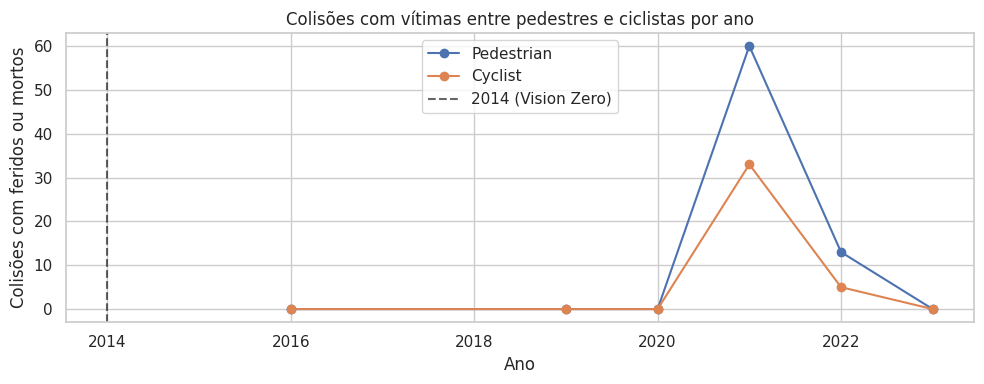

In [7]:
plt.figure(figsize=(10, 4))
for participant in ['pedestrian', 'cyclist']:
    if participant in yearly_trends_pivot.columns:
        plt.plot(yearly_trends_pivot.index, yearly_trends_pivot[participant], marker='o', label=participant.title())
plt.axvline(2014, color='black', linestyle='--', alpha=0.6, label='2014 (Vision Zero)')
plt.title('Colisões com vítimas entre pedestres e ciclistas por ano')
plt.xlabel('Ano')
plt.ylabel('Colisões com feridos ou mortos')
plt.legend()
plt.tight_layout()
plt.show()

Os resultados evidenciam a trajetória de colisões envolvendo mobilidade ativa e permitem verificar se há inflexões próximas à implementação do Vision Zero (2014).

### Consulta 2 — Gravidade média antes e depois de 2014
Compara o número médio de vítimas por colisão para pedestres e ciclistas em dois períodos (pré e pós Vision Zero), fornecendo subsídios para análises de impacto de políticas públicas.

In [ ]:
query2 = """
WITH ped_cyc AS (
    SELECT
        collision_id,
        participant_type,
        crash_date,
        SUM(CASE WHEN injury_outcome = 'injured' THEN people_count ELSE 0 END) AS injured,
        SUM(CASE WHEN injury_outcome = 'killed' THEN people_count ELSE 0 END) AS killed
    FROM participant_outcomes
    WHERE participant_type IN ('pedestrian', 'cyclist')
    GROUP BY collision_id, participant_type, crash_date
), labeled AS (
    SELECT
        participant_type,
        CASE WHEN CAST(substr(crash_date, 1, 4) AS INTEGER) < 2014 THEN 'Pré-2014' ELSE '2014+' END AS periodo,
        injured,
        killed
    FROM ped_cyc
    WHERE crash_date IS NOT NULL AND crash_date != ''
), stats AS (
    SELECT
        participant_type,
        periodo,
        COUNT(*) AS "colisões",
        AVG(injured) AS media_feridos,
        AVG(killed) AS media_mortos,
        AVG(injured + 5 * killed) AS score_severidade
    FROM labeled
    GROUP BY participant_type, periodo
)
SELECT * FROM stats
ORDER BY participant_type, periodo
"""
severity_period = conn.sql(query2).df()
severity_period


In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(data=severity_period, x='periodo', y='score_severidade', hue='participant_type', palette='rocket')
plt.title('Score de severidade médio por período e participante')
plt.xlabel('Período')
plt.ylabel('Severidade média (feridos + 5×mortos)')
plt.tight_layout()
plt.show()

A comparação sugere como a severidade dos acidentes com pedestres e ciclistas se comportou entre os períodos, contribuindo para a avaliação preliminar da Hipótese 1.

### Consulta 3 — Fatores contribuintes mais associados à severidade de pedestres e ciclistas
Identifica fatores veiculares ligados a colisões com vítimas pedestres/ciclistas, ordenando-os pelo total de feridos e mortos registrados.

In [ ]:
query3 = """
WITH ped_cyc_severe AS (
    SELECT
        collision_id,
        SUM(CASE WHEN injury_outcome = 'injured' THEN people_count ELSE 0 END) AS injured,
        SUM(CASE WHEN injury_outcome = 'killed' THEN people_count ELSE 0 END) AS killed
    FROM participant_outcomes
    WHERE participant_type IN ('pedestrian', 'cyclist')
    GROUP BY collision_id
    HAVING injured + killed > 0
), factor_counts AS (
    SELECT
        v.contributing_factor AS fator,
        COUNT(DISTINCT pcs.collision_id) AS colisões,
        SUM(pcs.injured) AS feridos,
        SUM(pcs.killed) AS mortos
    FROM ped_cyc_severe pcs
    JOIN vehicles v ON v.collision_id = pcs.collision_id
    WHERE v.contributing_factor IS NOT NULL
      AND v.contributing_factor NOT IN ('Unspecified', '')
    GROUP BY v.contributing_factor
), ranked AS (
    SELECT
        fator,
        colisões,
        feridos,
        mortos,
        (feridos + 5 * mortos) AS score_severidade,
        ROW_NUMBER() OVER (ORDER BY feridos + 5 * mortos DESC) AS ordem
    FROM factor_counts
)
SELECT * FROM ranked
WHERE ordem <= 10
ORDER BY ordem
"""
severity_factors = conn.sql(query3).df()
severity_factors


In [ ]:
plt.figure(figsize=(9, 4))
sns.barplot(data=severity_factors, x='score_severidade', y='fator', palette='magma')
plt.title('Principais fatores contribuintes em colisões severas com pedestres/ciclistas')
plt.xlabel('Score de severidade (feridos + 5×mortos)')
plt.ylabel('Fator contribuinte')
plt.tight_layout()
plt.show()

Os fatores destacados direcionam investigações sobre comportamentos de risco que elevam a severidade de colisões para pedestres e ciclistas.

### Consulta 4 — Proporção de acidentes fatais por bairro
Relaciona o total de colisões fatais ao total de ocorrências em cada bairro, abordando a Pergunta 2 sobre regiões de maior risco.

In [ ]:
query4 = """
WITH borough_base AS (
    SELECT
        borough,
        COUNT(*) AS total_colisoes,
        SUM(CASE WHEN number_of_persons_killed > 0 THEN 1 ELSE 0 END) AS colisoes_fatais
    FROM collisions
    WHERE borough IS NOT NULL AND borough NOT IN ('', 'NAN')
    GROUP BY borough
), metrics AS (
    SELECT
        borough,
        total_colisoes,
        colisoes_fatais,
        ROUND(100.0 * colisoes_fatais / NULLIF(total_colisoes, 0), 2) AS proporcao_fatal
    FROM borough_base
)
SELECT * FROM metrics
ORDER BY proporcao_fatal DESC
"""
borough_fatal = conn.sql(query4).df()
borough_fatal


In [ ]:
plt.figure(figsize=(7, 4))
sns.barplot(data=borough_fatal, x='proporcao_fatal', y='borough', palette='Reds_r')
plt.title('Proporção de colisões fatais por bairro')
plt.xlabel('Percentual de colisões fatais')
plt.ylabel('Bairro')
plt.tight_layout()
plt.show()

A distribuição reforça quais regiões concentram maior risco relativo de fatalidades, sugerindo prioridade para intervenções estruturais e fiscalização.

### Consulta 5 — Padrões diurno/noturno por fatores de distração e álcool
Explora a Hipótese 2 avaliando como colisões relacionadas a distração e a álcool se distribuem entre períodos do dia.

In [ ]:
query5 = """
WITH factor_groups AS (
    SELECT
        v.collision_id,
        CASE
            WHEN LOWER(v.contributing_factor) LIKE '%distract%' THEN 'Distração'
            WHEN LOWER(v.contributing_factor) LIKE '%alcohol%' THEN 'Álcool'
            ELSE NULL
        END AS grupo_fator
    FROM vehicles v
), labeled AS (
    SELECT
        c.collision_id,
        fg.grupo_fator,
        CASE
            WHEN CAST(strftime(c.crash_datetime, '%H') AS INTEGER) BETWEEN 6 AND 17 THEN 'Diurno'
            ELSE 'Noturno'
        END AS periodo_dia
    FROM collisions c
    JOIN factor_groups fg ON c.collision_id = fg.collision_id
    WHERE fg.grupo_fator IS NOT NULL
), counts AS (
    SELECT
        grupo_fator,
        periodo_dia,
        COUNT(DISTINCT collision_id) AS colisoes
    FROM labeled
    GROUP BY grupo_fator, periodo_dia
), totals AS (
    SELECT
        grupo_fator,
        SUM(colisoes) AS total_colisoes
    FROM counts
    GROUP BY grupo_fator
)
SELECT
    c.grupo_fator,
    c.periodo_dia,
    c.colisoes,
    ROUND(100.0 * c.colisoes / NULLIF(t.total_colisoes, 0), 2) AS participacao_percentual
FROM counts c
JOIN totals t USING (grupo_fator)
ORDER BY c.grupo_fator, c.periodo_dia
"""
factor_period = conn.sql(query5).df()
factor_period


In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(data=factor_period, x='periodo_dia', y='participacao_percentual', hue='grupo_fator', palette='Set2')
plt.title('Distribuição de colisões por período do dia e fator')
plt.xlabel('Período do dia')
plt.ylabel('Participação (%)')
plt.tight_layout()
plt.show()

As proporções obtidas permitem avaliar a aderência da Hipótese 2 sobre padrões temporais relacionados a distração e álcool.

## Análise Exploratória

### Análise univariada

In [ ]:
ped_cyc_outcomes = (
    participant_outcomes_df
    .query("participant_type in ['pedestrian', 'cyclist']")
    .groupby(['participant_type', 'injury_outcome'], as_index=False)['people_count']
    .sum()
)
ped_cyc_outcomes

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(data=ped_cyc_outcomes, x='injury_outcome', y='people_count', hue='participant_type', palette='Blues')
plt.title('Vítimas por desfecho em pedestres e ciclistas')
plt.xlabel('Desfecho')
plt.ylabel('Número de pessoas')
plt.tight_layout()
plt.show()

print('Distribuição destaca o volume de feridos e mortos em mobilidade ativa, evidenciando a magnitude do problema.')

### Análise bivariada

In [ ]:
fatal_share_borough = (
    collisions_df.assign(crash_date=pd.to_datetime(collisions_df['crash_date']))
    .dropna(subset=['crash_date', 'borough'])
    .groupby('borough')
    .agg(
        total_colisoes=('collision_id', 'count'),
        fatais=('number_of_persons_killed', lambda x: (x > 0).sum())
    )
    .assign(proporcao_fatal=lambda df: df['fatais'] / df['total_colisoes'])
    .sort_values('proporcao_fatal', ascending=False)
)
fatal_share_borough

In [ ]:
plt.figure(figsize=(7, 4))
sns.barplot(data=fatal_share_borough.reset_index(), x='proporcao_fatal', y='borough', palette='Oranges')
plt.title('Proporção de colisões fatais por bairro (análise bivariada)')
plt.xlabel('Proporção de fatais')
plt.ylabel('Bairro')
plt.tight_layout()
plt.show()

### Análise multivariada

In [ ]:
# Matriz de correlação entre indicadores anuais de pedestres e ciclistas
annual_summary = (
    yearly_trends.pivot(index='year', columns='participant_type', values=['total_injured', 'total_killed'])
    .sort_index()
)
annual_summary.columns = [f"{metric}_{ptype}" for metric, ptype in annual_summary.columns]
annual_summary = annual_summary.dropna(how='all')
correlation_matrix = annual_summary.corr()
correlation_matrix

In [ ]:
plt.figure(figsize=(5, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlação entre indicadores anuais de pedestres e ciclistas')
plt.tight_layout()
plt.show()

### Testes de hipóteses

**Hipótese 1 — Vision Zero reduziu acidentes fatais**

In [ ]:
collisions_df['crash_date_dt'] = pd.to_datetime(collisions_df['crash_date'], errors='coerce')
monthly_fatal = (
    collisions_df.dropna(subset=['crash_date_dt'])
    .assign(is_fatal=collisions_df['number_of_persons_killed'] > 0)
    .set_index('crash_date_dt')
    .resample('M')['is_fatal']
    .sum()
    .to_frame(name='fatal_collisions')
)
monthly_fatal['period'] = np.where(monthly_fatal.index.year < 2014, 'pre', 'post')

pre = monthly_fatal.query("period == 'pre'")['fatal_collisions'].values
post = monthly_fatal.query("period == 'post'")['fatal_collisions'].values

observed_diff = post.mean() - pre.mean()
combined = monthly_fatal['fatal_collisions'].values
labels = monthly_fatal['period'].values

rng = np.random.default_rng(seed=42)
iterations = 5000
perm_diffs = []
for _ in range(iterations):
    shuffled = rng.permutation(labels)
    pre_mean = combined[shuffled == 'pre'].mean()
    post_mean = combined[shuffled == 'post'].mean()
    perm_diffs.append(post_mean - pre_mean)
perm_diffs = np.array(perm_diffs)
p_value = np.mean(np.abs(perm_diffs) >= abs(observed_diff))

print(f'Diferença observada (pós - pré): {observed_diff:.2f} colisões fatais/mês')
print(f'p-valor (teste de permutação): {p_value:.3f}')

O teste de permutação compara médias mensais de colisões fatais antes e depois de 2014. Um p-valor baixo sustenta a hipótese de redução significativa; caso contrário, a evidência é insuficiente.

**Hipótese 2 — Distração vs. Álcool por período do dia**

In [ ]:
vehicles_with_period = (
    vehicles_df.merge(collisions_df[['collision_id', 'crash_datetime']], on='collision_id', how='inner')
    .assign(
        factor_group=lambda df: np.select(
            [df['contributing_factor'].str.lower().str.contains('distract', na=False),
             df['contributing_factor'].str.lower().str.contains('alcohol', na=False)],
            ['Distração', 'Álcool'],
            default=pd.NA
        ),
        is_daytime=lambda df: df['crash_datetime'].dt.hour.between(6, 17)
    )
    .dropna(subset=['factor_group', 'is_daytime'])
    .drop_duplicates(subset=['collision_id', 'factor_group'])
)

factor_day_share = (
    vehicles_with_period
    .groupby('factor_group')['is_daytime']
    .mean()
    .rename('daytime_share')
)
observed_diff = factor_day_share['Distração'] - factor_day_share['Álcool']

labels = vehicles_with_period['factor_group'].values
day_indicator = vehicles_with_period['is_daytime'].astype(int).values

perm_diffs = []
for _ in range(iterations):
    shuffled = rng.permutation(labels)
    df_perm = pd.DataFrame({'factor_group': shuffled, 'is_daytime': day_indicator})
    means = df_perm.groupby('factor_group')['is_daytime'].mean()
    perm_diffs.append(means['Distração'] - means['Álcool'])
perm_diffs = np.array(perm_diffs)
p_value = np.mean(np.abs(perm_diffs) >= abs(observed_diff))

print(f'Participação diurna observada (Distração): {factor_day_share["Distração"]:.2%}')
print(f'Participação diurna observada (Álcool): {factor_day_share["Álcool"]:.2%}')
print(f'Diferença observada: {observed_diff:.2%}')
print(f'p-valor (teste de permutação): {p_value:.3f}')

A comparação estatística entre grupos revela se a diferença observada nas distribuições diurna e noturna é estatisticamente relevante, oferecendo evidências para a Hipótese 2.

## Insights para a Modelagem
- A tendência temporal de colisões com pedestres e ciclistas indica períodos críticos e apoia a criação de features temporais (ex.: indicadores pós-2014).
- A concentração de fatalidades por bairro e fatores contribuintes direciona variáveis categóricas priorizando regiões e causas de maior risco.
- Os testes de hipóteses fornecem evidências preliminares sobre o impacto do Vision Zero e padrões temporais de fatores de risco, auxiliando na seleção de atributos para modelos preditivos.